In [1]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Define a transform to normalize the data
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.5,), (0.5,)),
                               ])
torch.manual_seed(42)
# Download and load the training data
trainset = datasets.MNIST('~/.pytorch/MNIST_data/', download=True, train=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

# Download and load the test data
testset = datasets.MNIST('~/.pytorch/MNIST_data/', download=True, train=False, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=True)

print(f"Training set size: {len(trainset)}")
print(f"Test set size: {len(testset)}")

Training set size: 60000
Test set size: 10000


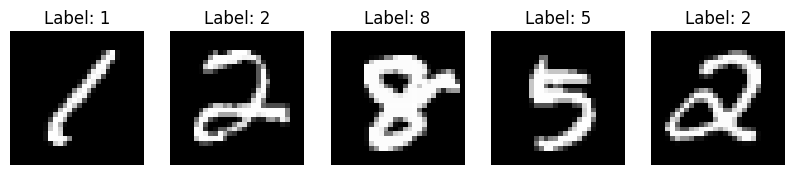

In [2]:
# Visualize some sample images from the dataset
images, labels = next(iter(trainloader))

fig, axes = plt.subplots(figsize=(10, 4), ncols=5)
for i in range(5):
    ax = axes[i]
    ax.imshow(images[i].numpy().squeeze(), cmap='gray')
    ax.set_title(f'Label: {labels[i].item()}')
    ax.axis('off')
plt.show()

In [3]:
# Filter indices for even digits (0, 2, 4, 6, 8)
even_train_indices = [i for i, (_, label) in enumerate(trainset) if label % 2 == 0]
even_test_indices = [i for i, (_, label) in enumerate(testset) if label % 2 == 0]

# Create Subsets using the filtered indices
even_trainset = torch.utils.data.Subset(trainset, even_train_indices)
even_testset = torch.utils.data.Subset(testset, even_test_indices)

# Create DataLoaders for the even-only datasets
even_trainloader = torch.utils.data.DataLoader(even_trainset, batch_size=64, shuffle=True)
even_testloader = torch.utils.data.DataLoader(even_testset, batch_size=64, shuffle=False)

print(f"Even digits training set size: {len(even_trainset)}")
print(f"Even digits test set size: {len(even_testset)}")

Even digits training set size: 29492
Even digits test set size: 4926


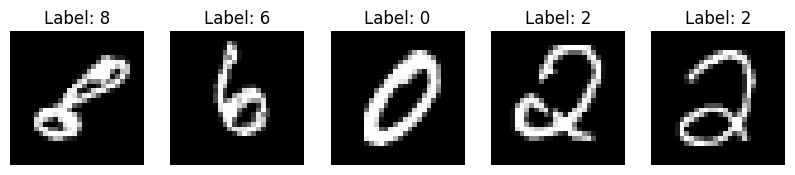

In [4]:
# Verify by visualizing a batch of the even-digit images
even_images, even_labels = next(iter(even_trainloader))

fig, axes = plt.subplots(figsize=(10, 4), ncols=5)
for i in range(5):
    ax = axes[i]
    ax.imshow(even_images[i].numpy().squeeze(), cmap='gray')
    ax.set_title(f'Label: {even_labels[i].item()}')
    ax.axis('off')
plt.show()

In [5]:
class KNNClassifier:
  def __init__(self, k):
    self.k = k

  def fit(self, X, y):
    self.X_train = X.view(X.shape[0], -1) # Shape: (N, 784)
    self.y_train = y

  def predict(self, X):
    X_test = X.view(X.shape[0], -1)
    # Step 1: Compute pairwise euclidean distances
    # Shape: (N_X_test, N_X_train)
    distances = torch.cdist(X_test, self.X_train)
    # Step 2: Find indices of the k smallest distances
    # Shape: (N_X_test, k)
    _, indices = torch.topk(distances, self.k, largest=False, dim=1)
    # Step 3: Gather the labels of the k nearest neighbors
    # Shape: (N_X_test, k)
    neighbor_labels = self.y_train[indices]
    # Step 4: Majority vote to find most frequent label
    predictions, _ = torch.mode(neighbor_labels, dim=1)
    return predictions

In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
param_grid = {'n_neighbors': range(1, 21)}

# 5-fold cross-validation
grid_search = GridSearchCV(knn, param_grid, cv=5)
grid_search.fit(even_images.view(even_images.shape[0], -1), even_labels)
k_optimal = grid_search.best_params_['n_neighbors']
print(f"The optimal K value is: {k_optimal}")

The optimal K value is: 1


In [7]:
classifier = KNNClassifier(k_optimal)
classifier.fit(even_images, even_labels)

even_test_images, even_test_labels = next(iter(even_testloader))
predicted = classifier.predict(even_test_images)

correct = (predicted == even_test_labels).sum().item()

# Calculate batch accuracy using the correct label size
accuracy = correct / even_test_labels.size(0)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9219


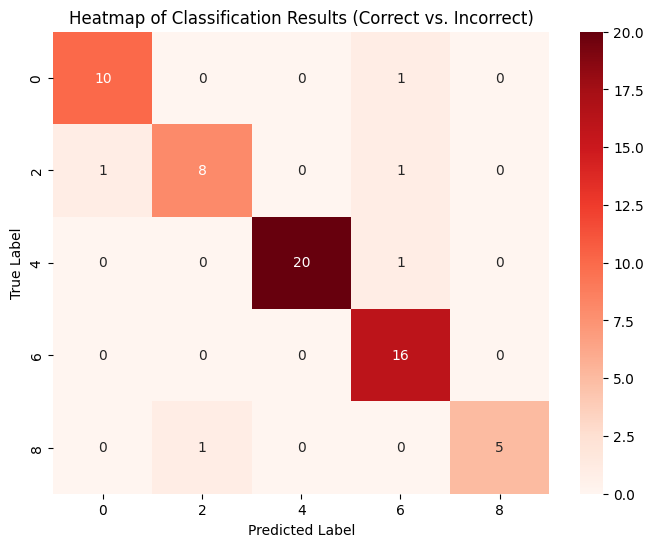

In [8]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd

# Get predictions for the entire test batch
even_test_images, even_test_labels = next(iter(even_testloader))
predicted = classifier.predict(even_test_images)

# Calculate the confusion matrix
cm = confusion_matrix(even_test_labels.numpy(), predicted.numpy(), labels=[0, 2, 4, 6, 8])

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=[0, 2, 4, 6, 8],
            yticklabels=[0, 2, 4, 6, 8])
plt.title('Heatmap of Classification Results (Correct vs. Incorrect)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

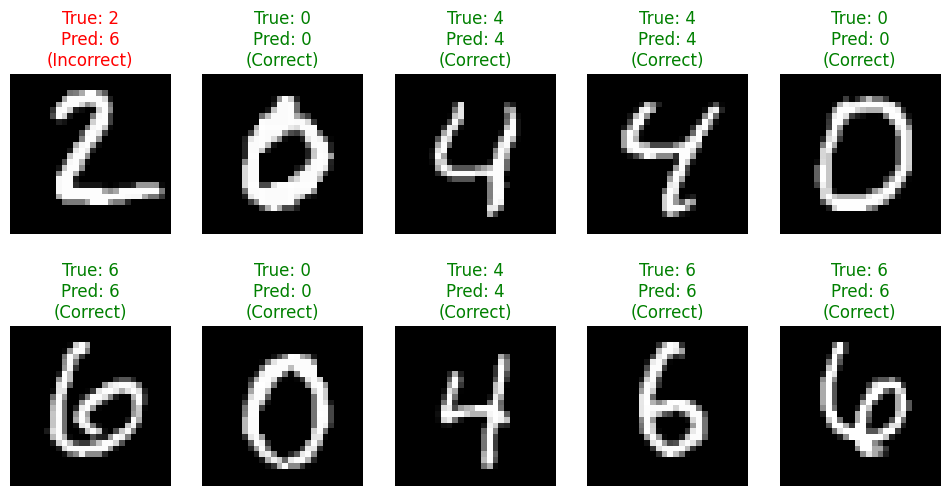

In [9]:
# Let's visualize a grid of predictions marking Correct (green) and Incorrect (red)
is_correct = (predicted == even_test_labels).numpy()

fig, axes = plt.subplots(figsize=(12, 6), nrows=2, ncols=5)
axes = axes.flatten()

for i in range(10):
    ax = axes[i]
    ax.imshow(even_test_images[i].numpy().squeeze(), cmap='gray')
    color = 'green' if is_correct[i] else 'red'
    status = 'Correct' if is_correct[i] else 'Incorrect'
    ax.set_title(f"True: {even_test_labels[i].item()}\nPred: {predicted[i].item()}\n({status})", color=color)
    ax.axis('off')

plt.show()

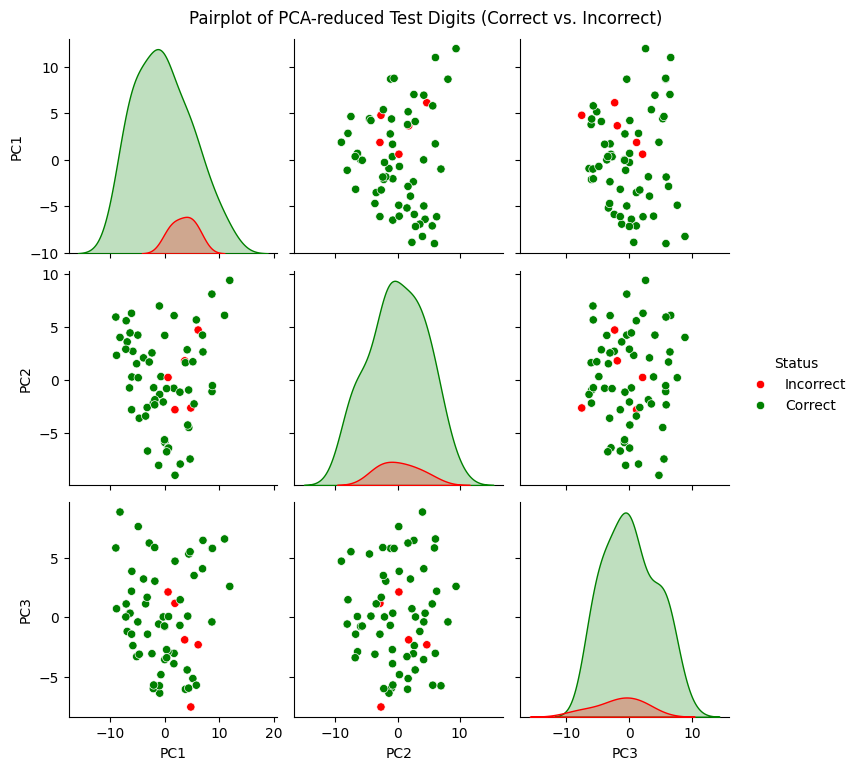

In [15]:
# pairplot for this dataset will be hard to read because it has 784 dimensions.
# we can use PCA to find 3 principal components and pairplot over them
from sklearn.decomposition import PCA

# Flatten the test images
X_test_flat = even_test_images.view(even_test_images.shape[0], -1).numpy()

# Reduce dimensions to 3 principal components
pca = PCA(n_components=3)
pca_results = pca.fit_transform(X_test_flat)

# Create a DataFrame for pair plotting
df = pd.DataFrame(pca_results, columns=['PC1', 'PC2', 'PC3'])
df['True Label'] = even_test_labels.numpy()
df['Prediction'] = predicted.numpy()
df['Status'] = ['Correct' if correct else 'Incorrect' for correct in is_correct]
# Plot pairplot
sns.pairplot(df, vars=['PC1', 'PC2', 'PC3'], hue='Status', palette={
    'Correct': 'green', 'Incorrect': 'red'}, diag_kind='kde')
plt.suptitle('Pairplot of PCA-reduced Test Digits (Correct vs. Incorrect)', y=1.02)
plt.show()